<a href="https://colab.research.google.com/github/ekyaaa/pengolahan-citra/blob/main/Week05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nama  : Ekya Muhammad Hasfi Fadlilurrahman <br>
Kelas : TI3H <br>
NIM   : 2341720111 <br>
Absen : 09

# **MODUL 6 – Histogram, Histogram Equalization, Dithering**

## **D1. Percobaan Histogram**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

<BarContainer object of 256 artists>

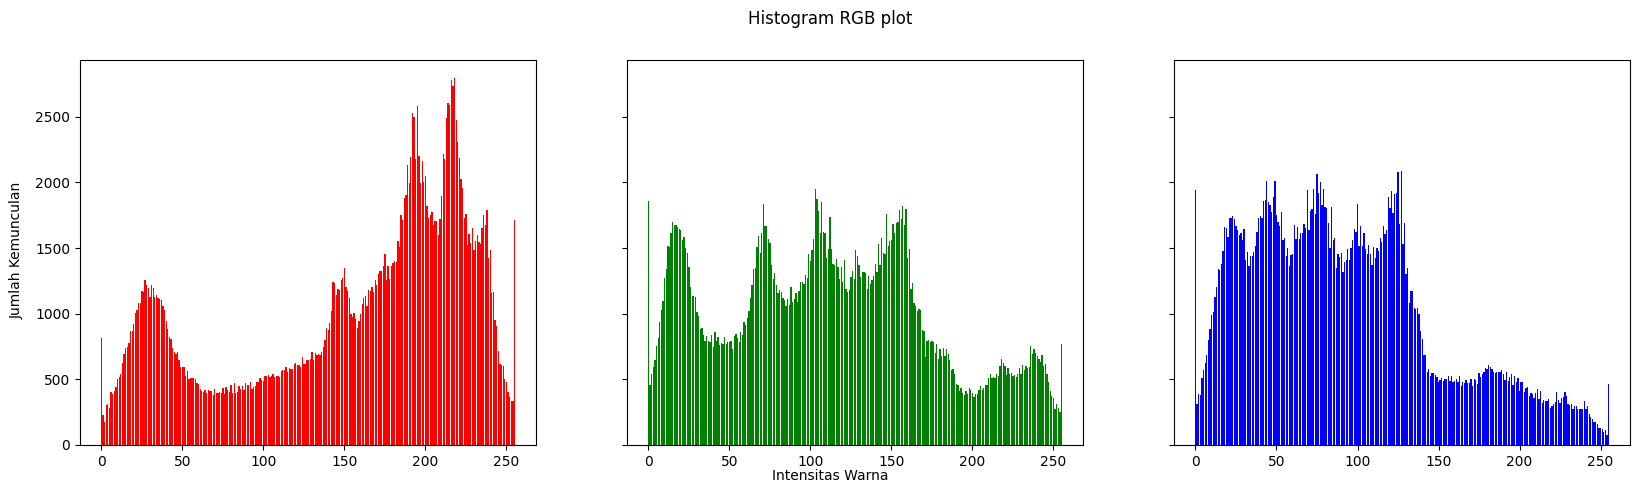

In [ ]:
img = cv.imread('/content/drive/MyDrive/pcvk_images/Images/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0] *256
blue = [0] *256

for y in range(0, height) :
  for x in range(0, width) :
    red [img [y] [x] [0]] += 1
    green [img [y] [x] [1]] += 1
    blue [img [y] [x] [2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs [2].bar(names, blue, color='blue')

### **PERTANYAAN PRAKTIKUM D1**



1. Buatlah histogram citra yang sama akan tetapi menggunakan library yang dimiliki oleh NumPy yaitu “histogram”. Bandingkan hasilnya. Apakah output muncul sama?  
- Sama.

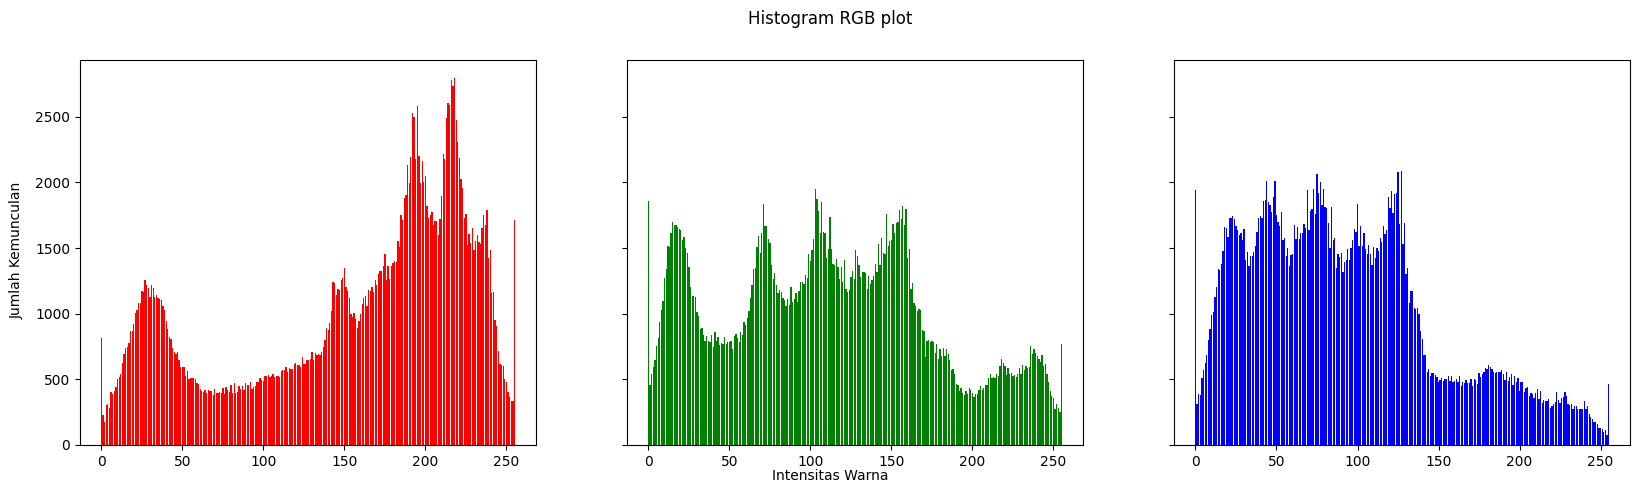

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img = cv.imread('/content/drive/MyDrive/pcvk_images/Images/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

red_channel = img[:,:,0]
green_channel = img[:,:,1]
blue_channel = img[:,:,2]

red_hist, _ = np.histogram(red_channel.ravel(), 256, [0,256])
green_hist, _ = np.histogram(green_channel.ravel(), 256, [0,256])
blue_hist, _ = np.histogram(blue_channel.ravel(), 256, [0,256])

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=(20,5), sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')

axs[0].bar(names, red_hist, color='red')
axs[1].bar(names, green_hist, color='green')
axs[2].bar(names, blue_hist, color='blue')

plt.show()


2. Buatlah histogram dengan menggunakan dengan menggunakan image KTM lama.jpg.
Analisis distribusi intensitas dari histogram yang dihasilkan apakah gambar cenderung gelap, terang, atau kontras rendah.  <br>
- Gambar sangat terang dan tidak terlalu kontras.

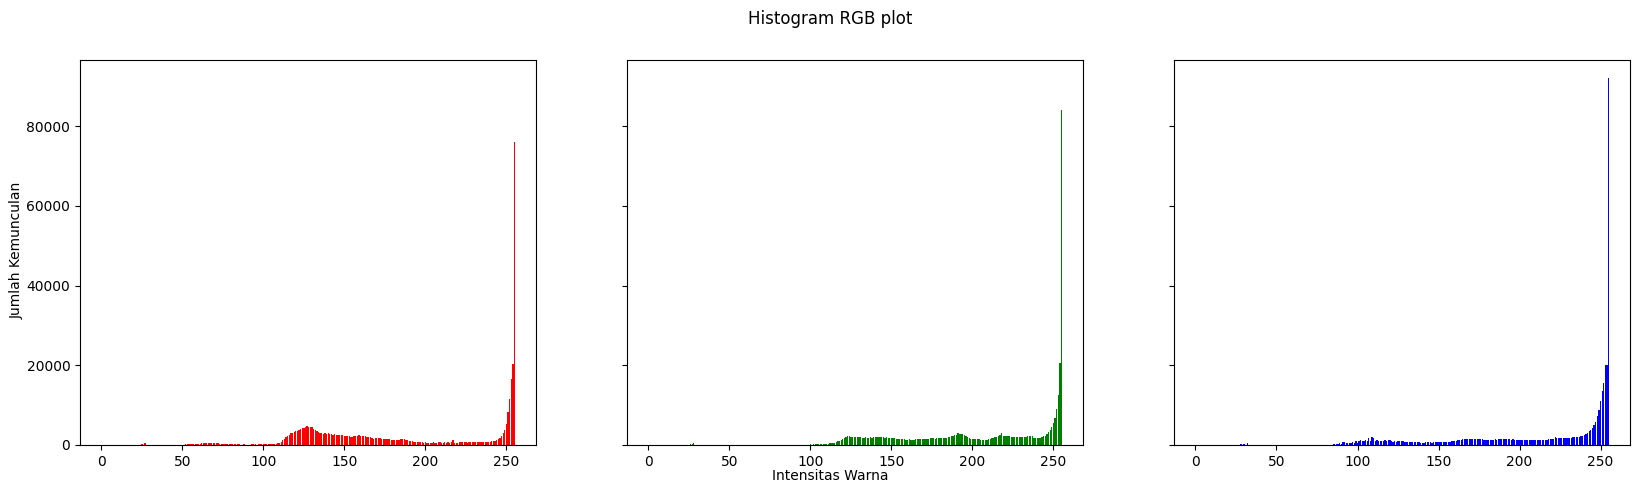

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Baca gambar dan konversi ke RGB
img = cv.imread('/content/drive/MyDrive/pcvk_images/Images/KTM lama.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)5

# Pisahkan channel
red_channel = img[:,:,0]
green_channel = img[:,:,1]
blue_channel = img[:,:,2]

# Hitung histogram tiap channel
red_hist, _ = np.histogram(red_channel.ravel(), 256, [0,256])
green_hist, _ = np.histogram(green_channel.ravel(), 256, [0,256])
blue_hist, _ = np.histogram(blue_channel.ravel(), 256, [0,256])

# Plot
names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=(20,5), sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')

axs[0].bar(names, red_hist, color='red')
axs[1].bar(names, green_hist, color='green')
axs[2].bar(names, blue_hist, color='blue')

plt.show()


## **D-2 PERCOBAAN HISTOGRAM EQUALIZATION**

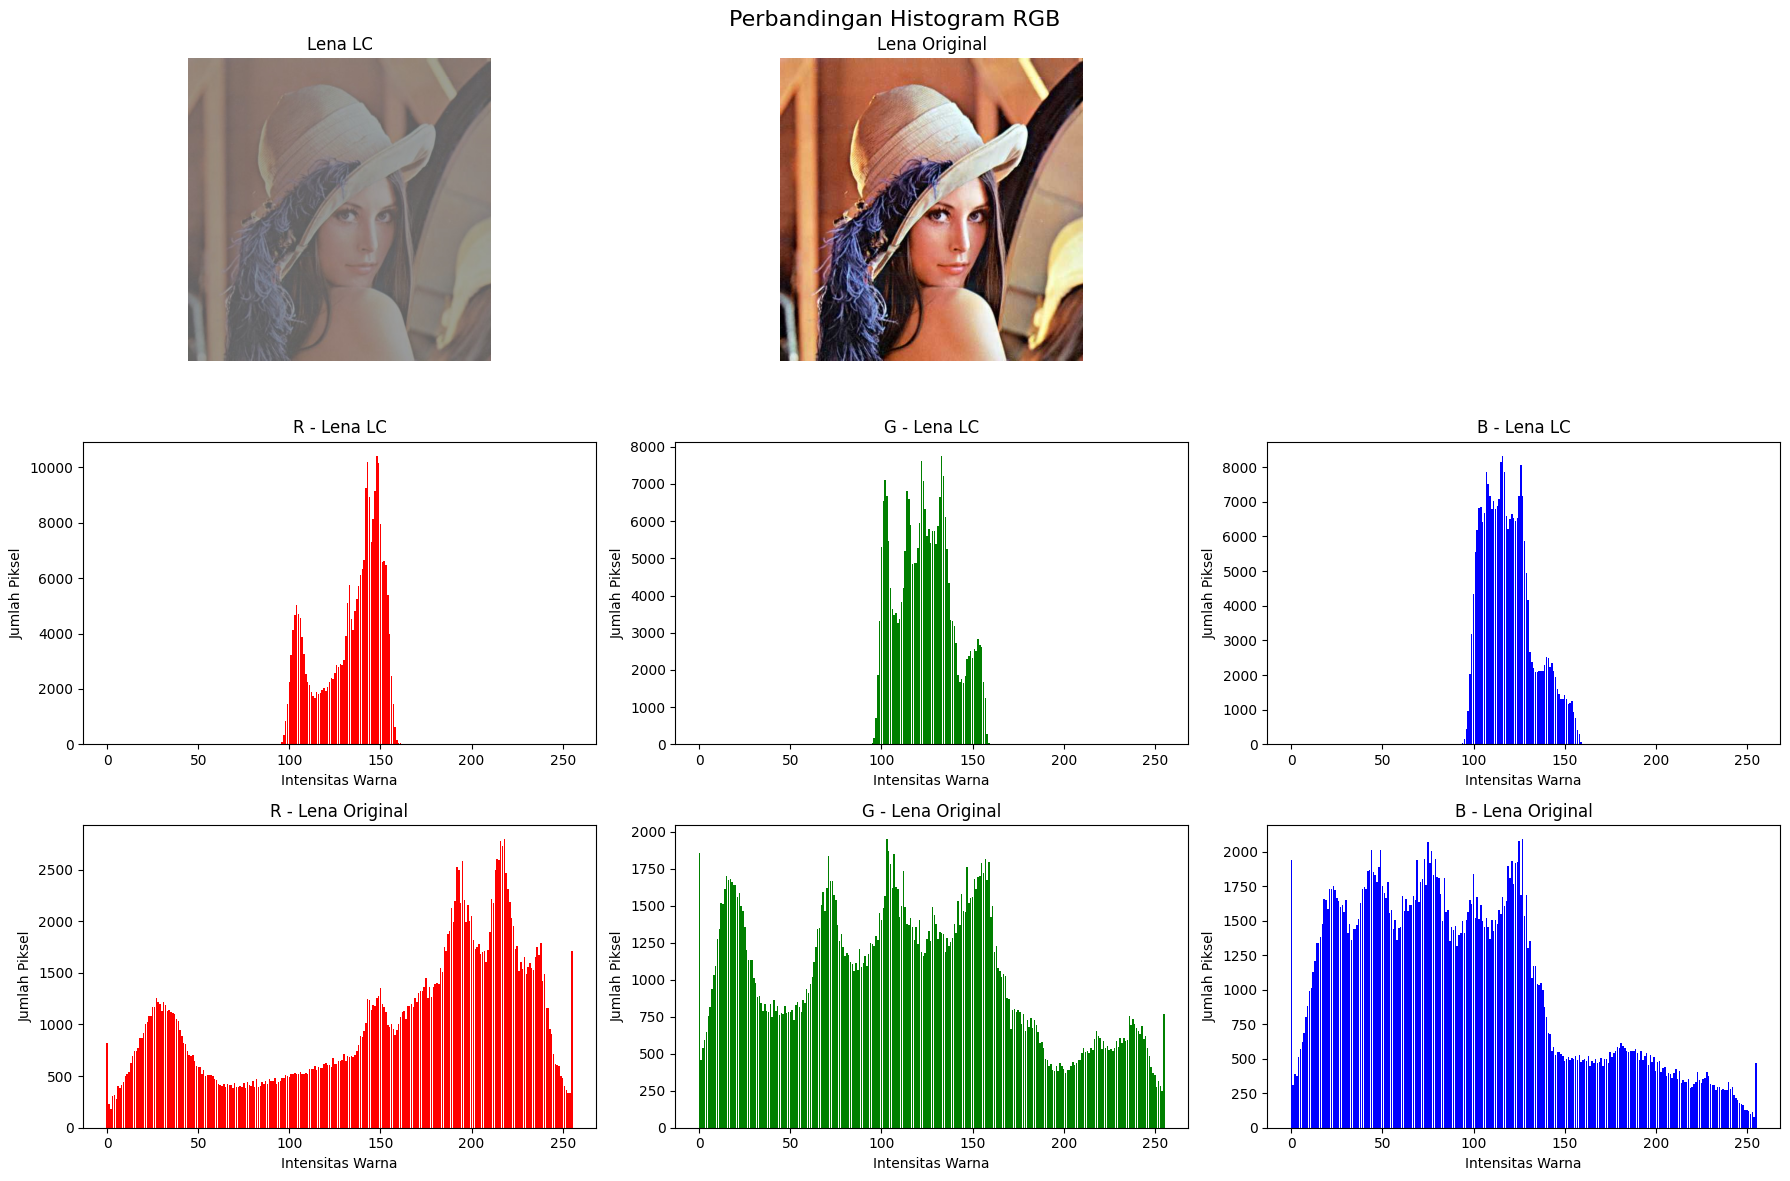

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img_1 = cv.imread('/content/drive/MyDrive/pcvk_images/Images/lena_lc.jpg')
img_2 = cv.imread('/content/drive/MyDrive/pcvk_images/Images/lena.jpg')
img_1 = cv.cvtColor(img_1, cv.COLOR_BGR2RGB)
img_2 = cv.cvtColor(img_2, cv.COLOR_BGR2RGB)

def get_hist(img):
    r, _ = np.histogram(img[:,:,0].ravel(), 256, [0,256])
    g, _ = np.histogram(img[:,:,1].ravel(), 256, [0,256])
    b, _ = np.histogram(img[:,:,2].ravel(), 256, [0,256])
    return r, g, b

red_hist_1, green_hist_1, blue_hist_1 = get_hist(img_1)
red_hist_2, green_hist_2, blue_hist_2 = get_hist(img_2)

names = np.arange(256)

fig, axs = plt.subplots(3, 3, figsize=(18,12))
fig.suptitle("Perbandingan Histogram RGB", fontsize=16)

axs[0,0].imshow(img_1)
axs[0,0].set_title("Lena LC")
axs[0,0].axis("off")

axs[0,1].imshow(img_2)
axs[0,1].set_title("Lena Original")
axs[0,1].axis("off")

axs[0,2].axis("off")

axs[1,0].bar(names, red_hist_1, color='red')
axs[1,0].set_title("R - Lena LC")
axs[1,1].bar(names, green_hist_1, color='green')
axs[1,1].set_title("G - Lena LC")
axs[1,2].bar(names, blue_hist_1, color='blue')
axs[1,2].set_title("B - Lena LC")

axs[2,0].bar(names, red_hist_2, color='red')
axs[2,0].set_title("R - Lena Original")
axs[2,1].bar(names, green_hist_2, color='green')
axs[2,1].set_title("G - Lena Original")
axs[2,2].bar(names, blue_hist_2, color='blue')
axs[2,2].set_title("B - Lena Original")

for ax in axs.flat:
    if ax not in [axs[0,0], axs[0,1]]:
        ax.set_xlabel("Intensitas Warna")
        ax.set_ylabel("Jumlah Piksel")

plt.tight_layout()
plt.show()


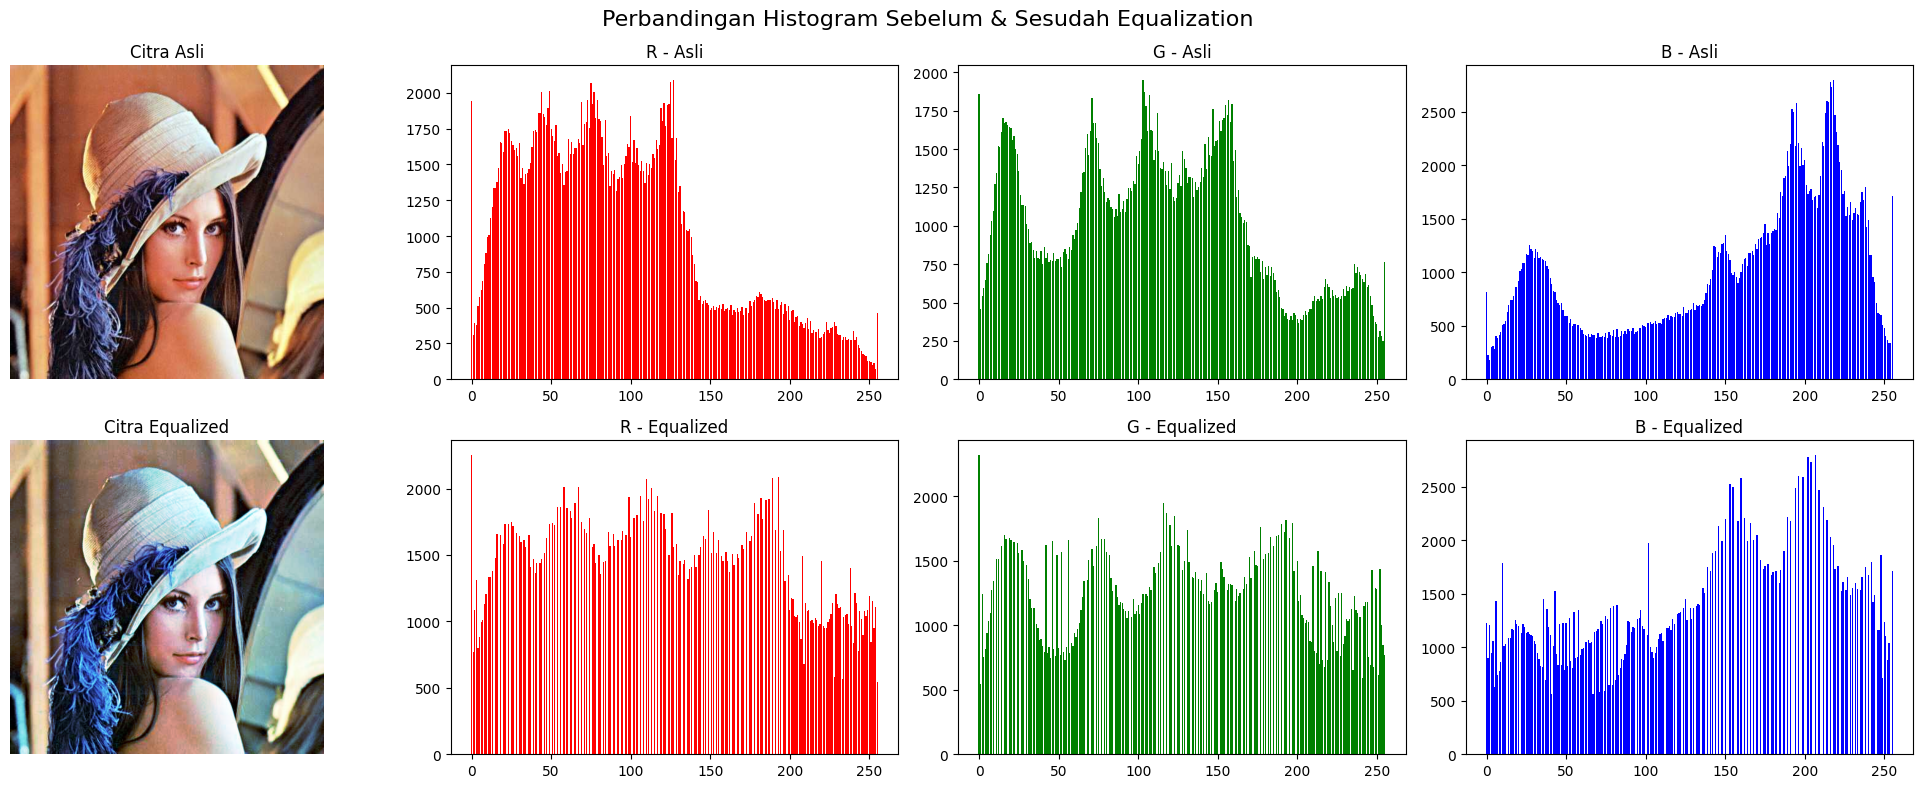

In [ ]:
'''
  2. Setelah mengerjakan langkah no. 1, buatlah histogram citra yang sama akan tetapi
    menggunakan library yang dimiliki oleh CV2 yaitu “equalizeHist” seperti pada
    potongan kode berikut ini. Lengkapi potongan kode tersebut! Bandingkan hasilnya.
    Apakah output muncul sama?
    - Tidak sama, hasil dari equalized terlihat kurang kontras.
'''
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Baca gambar
img = cv.imread('/content/drive/MyDrive/pcvk_images/Images/lena.jpg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Split channel
b, g, r = cv.split(img_rgb)

# Equalisasi tiap channel
b_eq = cv.equalizeHist(b)
g_eq = cv.equalizeHist(g)
r_eq = cv.equalizeHist(r)

# Satukan lagi setelah equalization
img_eq = cv.merge((b_eq, g_eq, r_eq))

# Histogram function
def get_hist(channel):
    hist, _ = np.histogram(channel.ravel(), 256, [0,256])
    return hist

names = np.arange(256)

# Histogram sebelum
r_hist = get_hist(r)
g_hist = get_hist(g)
b_hist = get_hist(b)

# Histogram sesudah
r_hist_eq = get_hist(r_eq)
g_hist_eq = get_hist(g_eq)
b_hist_eq = get_hist(b_eq)

# Plot hasil
fig, axs = plt.subplots(2, 4, figsize=(20,8))
fig.suptitle("Perbandingan Histogram Sebelum & Sesudah Equalization", fontsize=16)

# Gambar asli
axs[0,0].imshow(img_rgb)
axs[0,0].set_title("Citra Asli")
axs[0,0].axis("off")

# Histogram asli
axs[0,1].bar(names, r_hist, color='red')
axs[0,1].set_title("R - Asli")
axs[0,2].bar(names, g_hist, color='green')
axs[0,2].set_title("G - Asli")
axs[0,3].bar(names, b_hist, color='blue')
axs[0,3].set_title("B - Asli")

# Gambar hasil equalization
axs[1,0].imshow(img_eq)
axs[1,0].set_title("Citra Equalized")
axs[1,0].axis("off")

# Histogram equalized
axs[1,1].bar(names, r_hist_eq, color='red')
axs[1,1].set_title("R - Equalized")
axs[1,2].bar(names, g_hist_eq, color='green')
axs[1,2].set_title("G - Equalized")
axs[1,3].bar(names, b_hist_eq, color='blue')
axs[1,3].set_title("B - Equalized")

plt.tight_layout()
plt.show()


### **PERTANYAAN PRAKTIKUM D2**

1. Perbandingan Citra Lena <br>
a. Gunakan hasil histogram equalization pada citra lena.jpg. <br>
b. Hitung nilai PSNR antara citra asli dan citra hasil equalization<br>
c. Apakah nilai PSNR tinggi atau rendah? Apa arti nilai tersebut terhadap kualitas visual citra? Apakah ada detail baru yang muncul setelah equalization?

In [ ]:
# 1A

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Baca gambar
img = cv.imread('/content/drive/MyDrive/pcvk_images/Images/lena.jpg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Split channel
b, g, r = cv.split(img_rgb)

# Equalisasi tiap channel
b_eq = cv.equalizeHist(b)
g_eq = cv.equalizeHist(g)
r_eq = cv.equalizeHist(r)

# Satukan lagi setelah equalization
img_eq = cv.merge((b_eq, g_eq, r_eq))

# Histogram function
def get_hist(channel):
    hist, _ = np.histogram(channel.ravel(), 256, [0,256])
    return hist

names = np.arange(256)

# Histogram sebelum
r_hist = get_hist(r)
g_hist = get_hist(g)
b_hist = get_hist(b)

# Histogram sesudah
r_hist_eq = get_hist(r_eq)
g_hist_eq = get_hist(g_eq)
b_hist_eq = get_hist(b_eq)

# Plot hasil
fig, axs = plt.subplots(2, 4, figsize=(20,8))
fig.suptitle("Perbandingan Histogram Sebelum & Sesudah Equalization", fontsize=16)

# Gambar asli
axs[0,0].imshow(img_rgb)
axs[0,0].set_title("Citra Asli")
axs[0,0].axis("off")

# Histogram asli
axs[0,1].bar(names, r_hist, color='red')
axs[0,1].set_title("R - Asli")
axs[0,2].bar(names, g_hist, color='green')
axs[0,2].set_title("G - Asli")
axs[0,3].bar(names, b_hist, color='blue')
axs[0,3].set_title("B - Asli")

# Gambar hasil equalization
axs[1,0].imshow(img_eq)
axs[1,0].set_title("Citra Equalized")
axs[1,0].axis("off")

# Histogram equalized
axs[1,1].bar(names, r_hist_eq, color='red')
axs[1,1].set_title("R - Equalized")
axs[1,2].bar(names, g_hist_eq, color='green')
axs[1,2].set_title("G - Equalized")
axs[1,3].bar(names, b_hist_eq, color='blue')
axs[1,3].set_title("B - Equalized")

plt.tight_layout()
plt.show()

In [ ]:
# 1B

from math import log10
import numpy as np

def psnr(original, processed):
    mse = np.mean((original.astype(np.float32) - processed.astype(np.float32)) ** 2)
    if mse == 0:  # gambar sama persis
        return float('inf')
    PIXEL_MAX = 255.0
    return 10 * log10((PIXEL_MAX ** 2) / mse)

# Hitung PSNR antara citra asli dan equalized
psnr_value = psnr(img_rgb, img_eq)
print("PSNR antara citra asli dan citra equalized:", psnr_value, "dB")

PSNR antara citra asli dan citra equalized: 17.948401139690418 dB


1C. Nilai PSNR relatif lebih rendah dibandingkan dengan citra asli. Hal ini karena equalization mengubah distribusi intensitas piksel sehingga ada perbedaan numerik yang cukup besar terhadap citra awal. 17.948401139690418 dB artinya adalah perubahan cukup signifikan. Detail baru yang muncul adalah gambarnya menjadi cold/sedikit kebiru biruan dibandingkan yang original.

2. Gunakan Citra KTM Lama.jpg <br>
a. Terapkan histogram equalization pada citra KTM lama.jpg.<br>
b. Tampilkan citra asli, citra hasil equalization, serta histogram keduanya
dalam satu layout.<br>
c. Bandingkan citra KTM lama.jpg sebelum dan sesudah histogram equalization.
Jelaskan perbedaan yang terlihat secara visual (misalnya pada detail wajah,
teks, atau latar belakang). Apakah perubahan tersebut meningkatkan kualitas
informasi dari citra atau justru membuat citra terlihat terlalu “keras”.

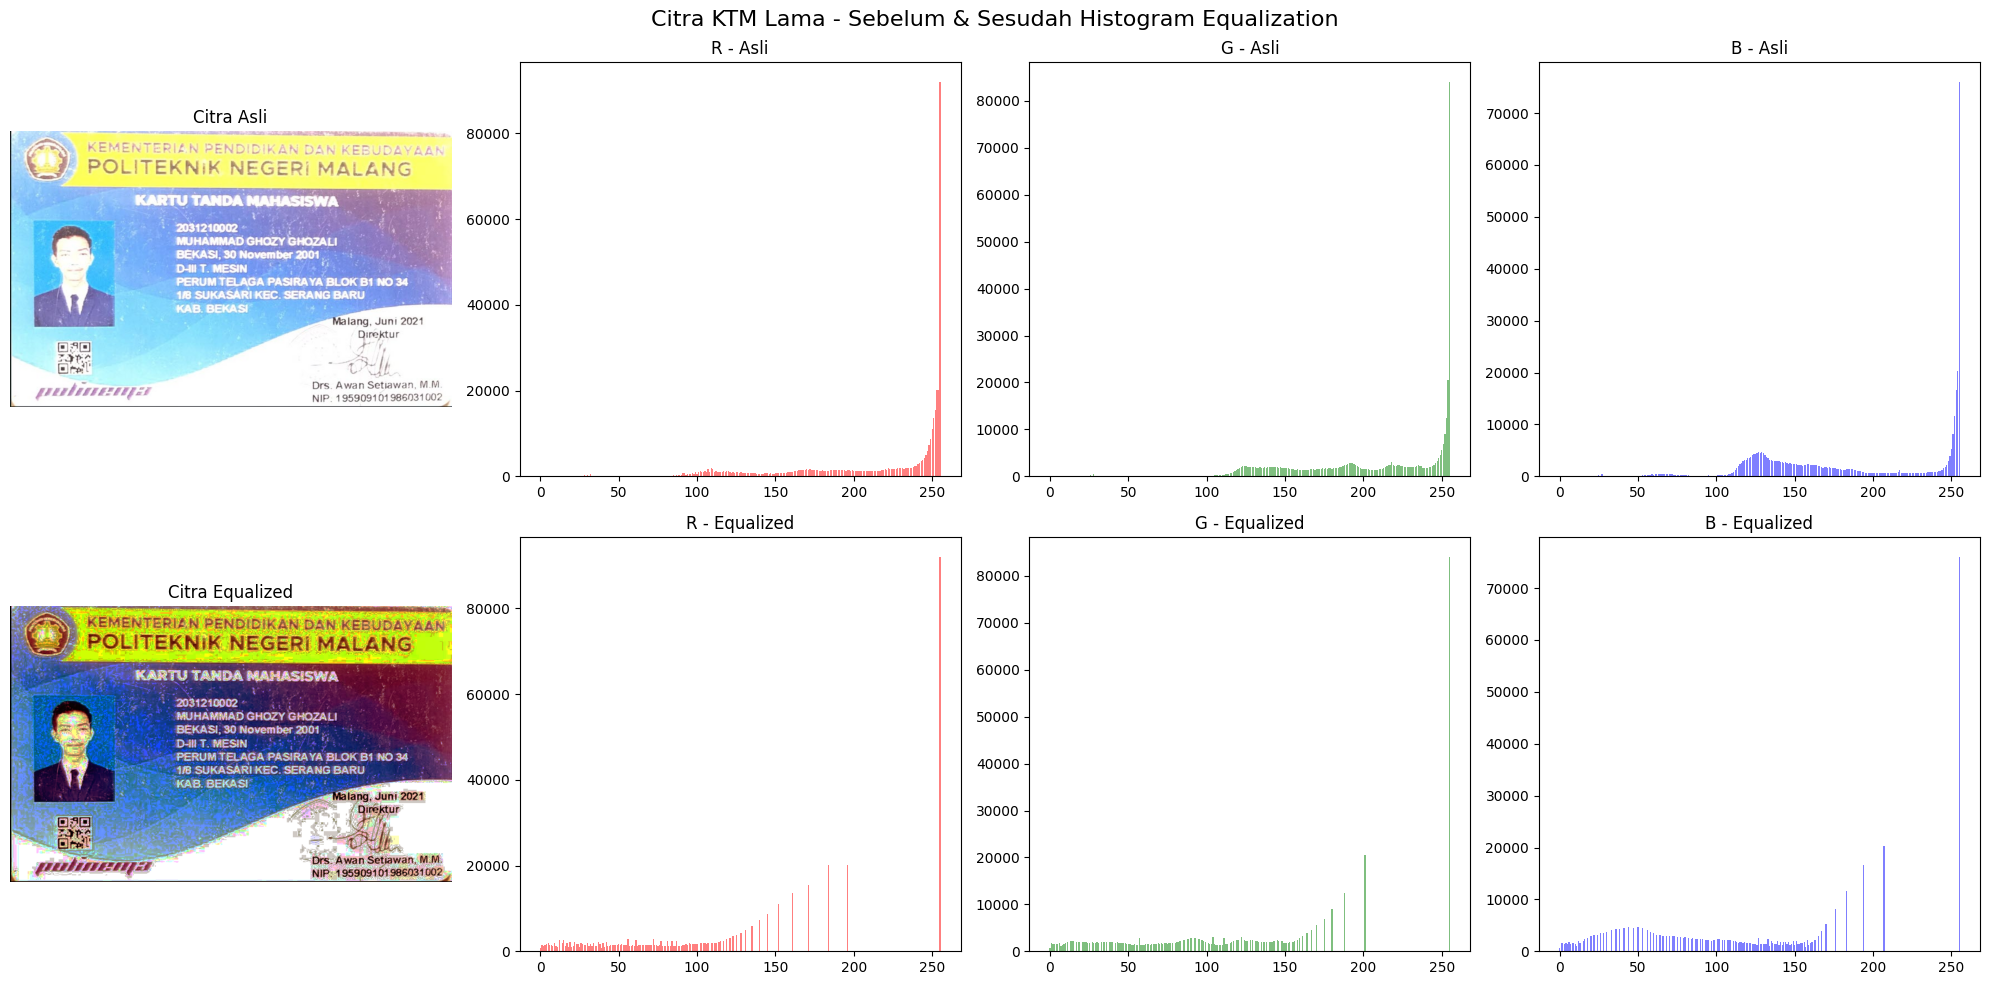

In [ ]:
# 2A, 2B, 2C
# - Terjadi penurunan intensitas cahaya yang meningkatkan readabilitas walaupun terlihat seperti tidak original lagi

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Baca citra KTM lama
img = cv.imread('/content/drive/MyDrive/pcvk_images/Images/KTM lama.jpg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Split channel
b, g, r = cv.split(img_rgb)

# Equalisasi tiap channel
b_eq = cv.equalizeHist(b)
g_eq = cv.equalizeHist(g)
r_eq = cv.equalizeHist(r)

# Satukan lagi setelah equalization
img_eq = cv.merge((b_eq, g_eq, r_eq))

# Fungsi hitung histogram per channel
def get_hist(channel):
    hist, _ = np.histogram(channel.ravel(), 256, [0,256])
    return hist

names = np.arange(256)

# Histogram sebelum equalization
r_hist = get_hist(r)
g_hist = get_hist(g)
b_hist = get_hist(b)

# Histogram setelah equalization
r_hist_eq = get_hist(r_eq)
g_hist_eq = get_hist(g_eq)
b_hist_eq = get_hist(b_eq)

# Layout: 2 baris gambar, 2 baris histogram
fig, axs = plt.subplots(2, 4, figsize=(20,10))
fig.suptitle("Citra KTM Lama - Sebelum & Sesudah Histogram Equalization", fontsize=16)

# Gambar asli
axs[0,0].imshow(img_rgb)
axs[0,0].set_title("Citra Asli")
axs[0,0].axis("off")

# Histogram asli
axs[0,1].bar(names, r_hist, color='red', alpha=0.5)
axs[0,1].set_title("R - Asli")
axs[0,2].bar(names, g_hist, color='green', alpha=0.5)
axs[0,2].set_title("G - Asli")
axs[0,3].bar(names, b_hist, color='blue', alpha=0.5)
axs[0,3].set_title("B - Asli")

# Gambar hasil equalization
axs[1,0].imshow(img_eq)
axs[1,0].set_title("Citra Equalized")
axs[1,0].axis("off")

# Histogram equalized
axs[1,1].bar(names, r_hist_eq, color='red', alpha=0.5)
axs[1,1].set_title("R - Equalized")
axs[1,2].bar(names, g_hist_eq, color='green', alpha=0.5)
axs[1,2].set_title("G - Equalized")
axs[1,3].bar(names, b_hist_eq, color='blue', alpha=0.5)
axs[1,3].set_title("B - Equalized")

plt.tight_layout()
plt.show()


## **D-3 TUGAS PRAKTIKUM DITHERING**

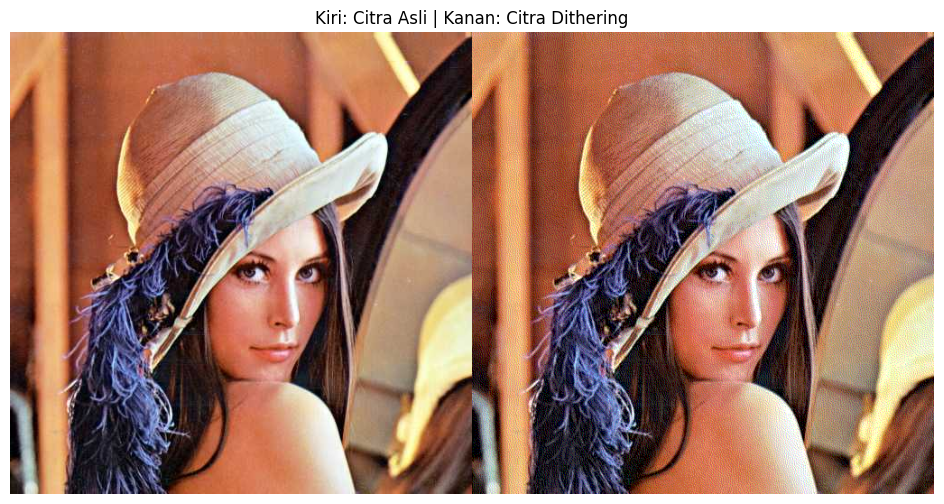

In [1]:
# 1

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Baca gambar
img = cv.imread('/content/drive/MyDrive/pcvk_images/Images/lena.jpg')
height, width, channels = img.shape

# Pisahkan channel dan ubah ke float32
imgB = img[:, :, 0].astype(np.float32)
imgG = img[:, :, 1].astype(np.float32)
imgR = img[:, :, 2].astype(np.float32)

jarakPixel = 5

def threshold(value):
    return np.clip(value, 0, 255)

# Looping tiap piksel
for y in range(height):
    for x in range(width):
        for channel in [imgB, imgG, imgR]:
            old = channel[y, x]
            new = np.round(jarakPixel * old / 255.0) * (255 / jarakPixel)
            channel[y, x] = new
            error = old - new

            if x + 1 < width:
                channel[y, x+1] = threshold(channel[y, x+1] + error * 7/16)
            if y + 1 < height and x - 1 >= 0:
                channel[y+1, x-1] = threshold(channel[y+1, x-1] + error * 5/16)
            if y + 1 < height:
                channel[y+1, x] = threshold(channel[y+1, x] + error * 3/16)
            if y + 1 < height and x + 1 < width:
                channel[y+1, x+1] = threshold(channel[y+1, x+1] + error * 1/16)

# Gabungkan channel kembali
img_dithered = cv.merge([
    imgB.astype(np.uint8),
    imgG.astype(np.uint8),
    imgR.astype(np.uint8)
])

# Gabungkan kiri-kanan
concat_img = np.concatenate((img, img_dithered), axis=1)

# Tampilkan
plt.figure(figsize=(12,6))
plt.imshow(cv.cvtColor(concat_img, cv.COLOR_BGR2RGB))
plt.title("Kiri: Citra Asli | Kanan: Citra Dithering")
plt.axis("off")
plt.show()


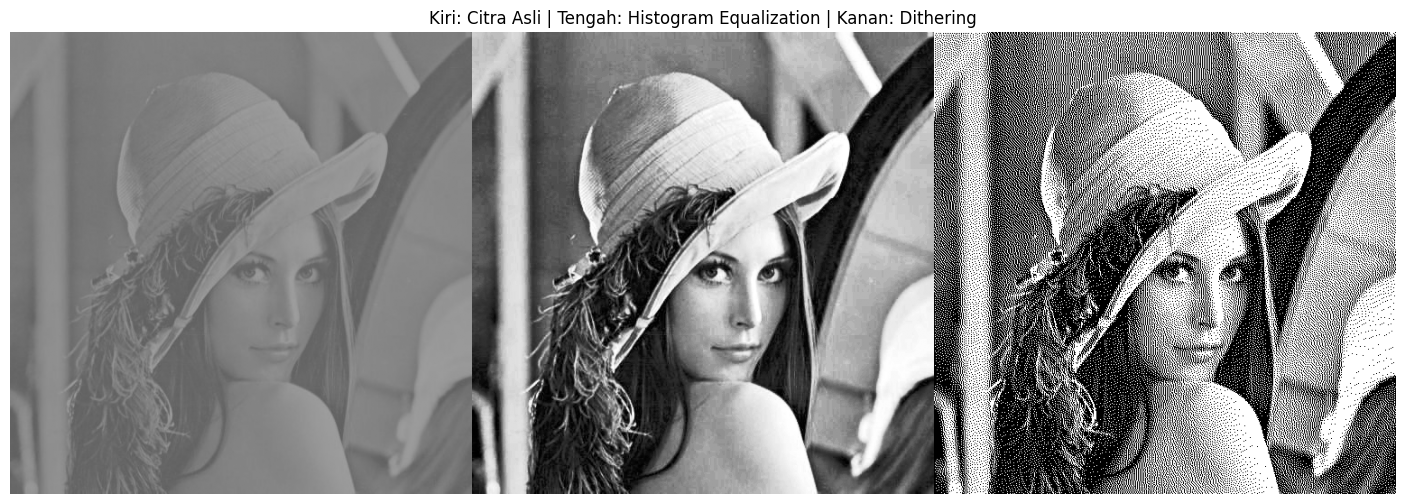

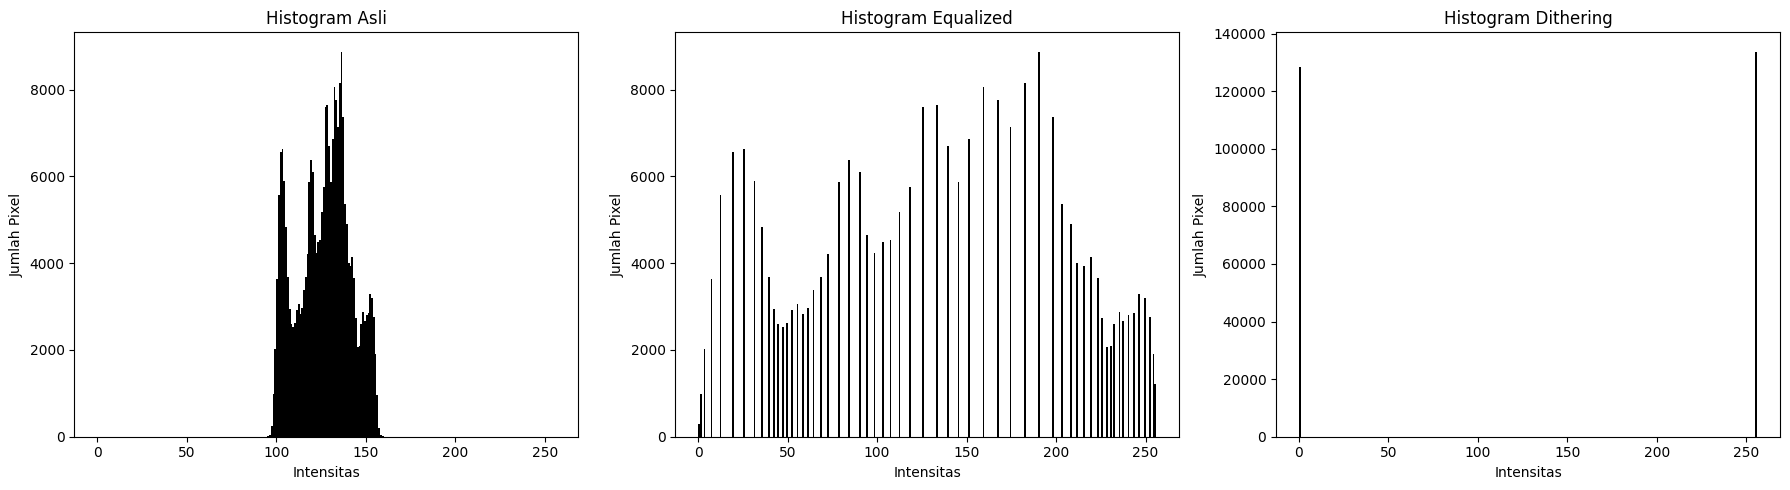

In [3]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Baca gambar dan ubah ke grayscale
img = cv.imread('/content/drive/MyDrive/pcvk_images/Images/lena_lc.jpg', cv.IMREAD_GRAYSCALE)

# Histogram Equalization
img_eq = cv.equalizeHist(img)

# Floyd–Steinberg Dithering
def floyd_steinberg_dithering(img):
    img = img.astype(np.float32)
    height, width = img.shape
    for y in range(height):
        for x in range(width):
            old_pixel = img[y, x]
            new_pixel = 0 if old_pixel < 128 else 255
            img[y, x] = new_pixel
            quant_error = old_pixel - new_pixel

            if x + 1 < width:
                img[y, x+1] += quant_error * 7/16
            if y + 1 < height and x - 1 >= 0:
                img[y+1, x-1] += quant_error * 5/16
            if y + 1 < height:
                img[y+1, x] += quant_error * 3/16
            if y + 1 < height and x + 1 < width:
                img[y+1, x+1] += quant_error * 1/16
    return np.clip(img, 0, 255).astype(np.uint8)

# Terapkan dithering pada citra hasil equalization
img_dithered = floyd_steinberg_dithering(img_eq)

# Gabungkan untuk perbandingan citra
concat_img = np.concatenate((img, img_eq, img_dithered), axis=1)

# ---- Plot Gambar ----
plt.figure(figsize=(18,6))
plt.imshow(concat_img, cmap='gray')
plt.title("Kiri: Citra Asli | Tengah: Histogram Equalization | Kanan: Dithering")
plt.axis("off")
plt.show()

# ---- Plot Histogram ----
images = [img, img_eq, img_dithered]
titles = ["Asli", "Equalized", "Dithering"]

plt.figure(figsize=(18,5))
for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.hist(images[i].ravel(), bins=256, range=[0,256], color='black')
    plt.title(f"Histogram {titles[i]}")
    plt.xlabel("Intensitas")
    plt.ylabel("Jumlah Pixel")
plt.tight_layout()
plt.show()
